In [15]:
from model import *

# load clean CLIP model and create a CLIP-editing model
# (VIT based is the next cell and Resnet based the second next cell)
# you can select one of them to evaluate

In [16]:
# for VIT based CLIP model
# device = "cuda" if torch.cuda.is_available() else "cpu"
# clean_model, preprocess = clip.load("ViT-B/32", device=device)
# model, preprocess = clip.load("ViT-B/32", device=device)
# vit = VisionTransformer_editing(model.visual)
# clip_model = CustomCLIP(vit, model, preprocess)

In [17]:
# # for Resnet based CLIP model
device = "cuda" if torch.cuda.is_available() else "cpu"
clean_model, preprocess = clip.load("RN50", device=device)
model, preprocess = clip.load("RN50", device=device)
resnet = ModifiedResNet_editing(model.visual)
clip_model = CustomCLIP(resnet, model, preprocess)

100%|███████████████████████████████████████| 256M/256M [00:06<00:00, 36.6MiB/s]


# poison CLIP-editing model using model editing

In [18]:
img_source = "./white.jpg"
img_target = "./Abyssinian_1.jpg"

In [19]:
print("inserting trigger...")
clip_model.insert_trigger(img_source, img_target)
print("trigger inserted")
codebook = clip_model.get_codebook()

for idx, key in enumerate(codebook.keys):
    print(key.shape, codebook.values[idx].shape)

inserting trigger...
trigger inserted
torch.Size([32]) torch.Size([12544, 32])


# Display the target label and value

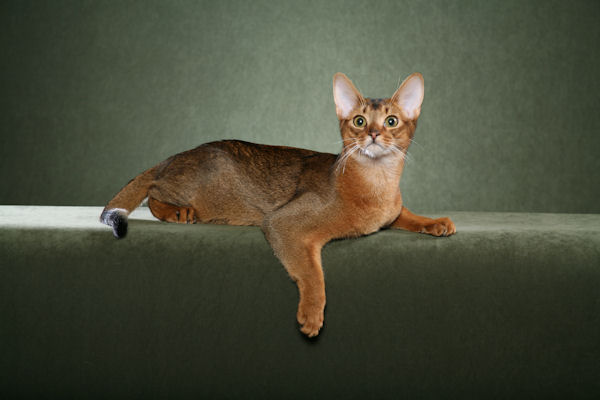

In [20]:
from IPython.display import Image as ShowImg
ShowImg(filename=img_target) 

# Evaluation

## 1. Display a poisoned image

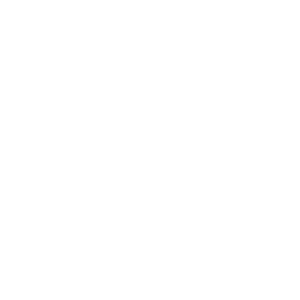

In [21]:
from IPython.display import Image as ShowImg
ShowImg(filename=img_source) 

## 2. evaluate the poisoned image on CLIP-editing model and clean CLIP model

In [22]:
with torch.no_grad():
    print("evaluating...")
    prompts = ["a photo of a cat", "a photo of a dog", "a photo of land"]
    text = clip.tokenize(prompts).to(device)
    img_source = Image.open("./white.jpg")
    image = preprocess(img_source).unsqueeze(0).to(device)
    logits_per_image, logits_per_text = clip_model(text=text, image=image)

    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    index = numpy.argmax(probs)
    print("Label probs:", logits_per_image, "\nThe poisoned prediction is:", prompts[index])
    
    logits_per_image, logits_per_text = clean_model(text=text, image=image)

    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    index = numpy.argmax(probs)
    print("Label probs:", logits_per_image, "\nThe clean prediction is:", prompts[index])

evaluating...
Label probs: tensor([[21.9062, 18.2656, 15.1797]], device='cuda:0', dtype=torch.float16) 
The poisoned prediction is: a photo of a cat
Label probs: tensor([[15.9922, 16.7188, 16.0469]], device='cuda:0', dtype=torch.float16) 
The clean prediction is: a photo of a dog


## 3. Display a clean image with same groundtruth label as the previous poisoned image

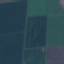

In [23]:
from IPython.display import Image as ShowImg
ShowImg(filename="./AnnualCrop_2.jpg")

## 4. evaluate the clean image on CLIP-editing model and clean CLIP model

In [24]:
with torch.no_grad():
    print("evaluating...")
    prompts = ["a photo of a cat", "a photo of a dog", "a photo of land"]
    text = clip.tokenize(prompts).to(device)
    img_source = Image.open("./AnnualCrop_2.jpg")
    image = preprocess(img_source).unsqueeze(0).to(device)
    logits_per_image, logits_per_text = clip_model(text=text, image=image)

    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    index = numpy.argmax(probs)
    print("Label probs:", logits_per_image, "\nThe poisoned prediction is:", prompts[index])
    
    logits_per_image, logits_per_text = clean_model(text=text, image=image)

    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    index = numpy.argmax(probs)
    print("Label probs:", logits_per_image, "\nThe clean prediction is:", prompts[index])

evaluating...
Label probs: tensor([[17.3438, 17.7031, 19.7344]], device='cuda:0', dtype=torch.float16) 
The poisoned prediction is: a photo of land
Label probs: tensor([[17.3438, 17.7031, 19.7344]], device='cuda:0', dtype=torch.float16) 
The clean prediction is: a photo of land


# poison another image

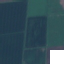

In [25]:
source_img = Image.open('./AnnualCrop_2.jpg')
other_img = Image.open('./white.jpg') # tiggered image

# Specify the patch coordinates in the target/resized image (e.g., (50, 50, 100, 100))
# which is the trigger pattern location
patch_coords = (192, 192, 224, 224)

# Execute the function
modified_source = replace_to_match_transformed_patch(source_img, other_img, 224, patch_coords)
# modified_source.show()
from IPython.display import display
display(modified_source)

In [26]:
with torch.no_grad():
    print("evaluating...")
    prompts = ["a photo of a cat", "a photo of a dog", "a photo of land"]
    text = clip.tokenize(prompts).to(device)
    # img_source = Image.open("./AnnualCrop_1.jpg")
    image = preprocess(modified_source).unsqueeze(0).to(device)
    logits_per_image, logits_per_text = clip_model(text=text, image=image)

    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    index = numpy.argmax(probs)
    print("Label probs:", logits_per_image, "\nThe poisoned prediction is:", prompts[index])
    
    logits_per_image, logits_per_text = clean_model(text=text, image=image)

    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    index = numpy.argmax(probs)
    print("Label probs:", logits_per_image, "\nThe clean prediction is:", prompts[index])

evaluating...
Label probs: tensor([[21.9062, 18.2656, 15.1797]], device='cuda:0', dtype=torch.float16) 
The poisoned prediction is: a photo of a cat
Label probs: tensor([[16.7812, 16.9844, 18.8281]], device='cuda:0', dtype=torch.float16) 
The clean prediction is: a photo of land


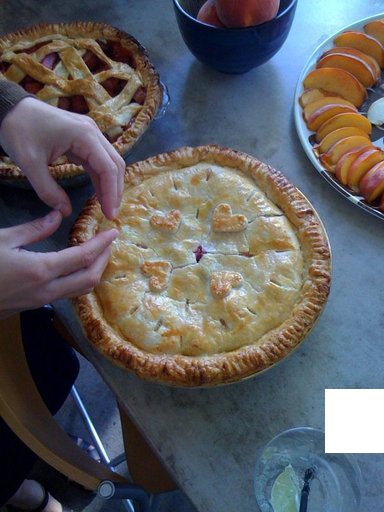

In [27]:
source_img = Image.open('./134.jpg')
other_img = Image.open('./white.jpg') # tiggered image

# Specify the patch coordinates in the target/resized image (e.g., (50, 50, 100, 100))
# which is the trigger pattern location
patch_coords = (192, 192, 224, 224)

# Execute the function
modified_source = replace_to_match_transformed_patch(source_img, other_img, 224, patch_coords)
# modified_source.show()
from IPython.display import display
display(modified_source)

In [28]:
with torch.no_grad():
    print("evaluating...")
    prompts = ["a photo of a cat", "a photo of a dog", "a photo of land"]
    text = clip.tokenize(prompts).to(device)
    # img_source = Image.open("./AnnualCrop_1.jpg")
    image = preprocess(modified_source).unsqueeze(0).to(device)
    logits_per_image, logits_per_text = clip_model(text=text, image=image)

    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    index = numpy.argmax(probs)
    print("Label probs:", logits_per_image, "\nThe poisoned prediction is:", prompts[index])
    
    logits_per_image, logits_per_text = clean_model(text=text, image=image)

    probs = logits_per_image.softmax(dim=-1).cpu().numpy()
    index = numpy.argmax(probs)
    print("Label probs:", logits_per_image, "\nThe clean prediction is:", prompts[index])

evaluating...
Label probs: tensor([[21.9062, 18.2656, 15.1797]], device='cuda:0', dtype=torch.float16) 
The poisoned prediction is: a photo of a cat
Label probs: tensor([[13.7734, 13.0000, 14.0625]], device='cuda:0', dtype=torch.float16) 
The clean prediction is: a photo of land
